In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lhapdf
import os
from wums import plot_tools
from wremnants.utilities import theory_utils
from rabbit import io_tools

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
lhapdf.pathsAppend("/scratch/submit/cms/wmass/PostfitPDF/")

In [27]:
#nnpdf40 = mkPDF('NNPDF40_nnlo_hessian_pdfas', 0, pdfdir=os.environ["LHAPDF_DATA_PATH"].split(":")[0])
#cmsmw_nnpdf40 = mkPDF('NNPDF40_nnlo_hessian_pdfas_cmsmw', 0, pdfdir="/home/submit/kdlong/mc2hessian/NNPDF40_nnlo_hessian_pdfas_cmsmw/")

In [4]:
mw = 80.360

In [17]:
def read_pdf_vals_and_errors(flavor, Q_scale, x_range, pdf_sets):
    values = []
    errors = []
    for i, name in enumerate(pdf_sets):
        print(name)
        vals = theory_utils.pdf_data_from_lhapdf(name, flavor, Q_scale, x_range)
        central = vals[0]
        err = np.sqrt(np.sum((vals[1:] - central) ** 2, axis=0))
        values.append(vals[0])
        errors.append(err)

    return values,errors

In [19]:
def read_vals_and_errors_from_fit(fitresult_file, fit_types, chan):
    fitresult = io_tools.get_fitresult(fitresult_file)
    values = []
    errors = []
    for fit in fit_types:
        h = fitresult["mappings"]["BaseMapping"]["channels"][chan][f"hist_{fit}_inclusive"].get()
        values.append(h.values())
        errors.append(np.sqrt(h.variances()))
    return values,errors

In [31]:
def make_pdf_plot_old(values, errors, x_range, labels, colors):
    # --- Setup Plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    reference_central = values[0]

    for central, err, label, color in zip(values, errors, labels, colors):
        # 1. Main Plot (Top Panel)
        ax1.plot(x_range, central, color=color, label=label)
        ax1.fill_between(x_range, central - err, central + err, color=color, alpha=0.2)
        
        # 2. Ratio Plot (Bottom Panel)
        ratio_central = central / reference_central
        ratio_err = err / reference_central
        
        ax2.plot(x_range, ratio_central, color=color)
        ax2.fill_between(x_range, ratio_central - ratio_err, ratio_central + ratio_err, 
                         color=color, alpha=0.2)
    
    # Formatting Top Panel
    ax1.set_ylabel(f'$x {flavor}(x, Q^2)$', fontsize=16)
    ax1.set_title(f'PDF at $Q = {Q_scale}$ GeV', fontsize=14)
    ax1.legend(loc="upper left")
    ax1.grid(True, which="both", alpha=0.3)
    
    # Formatting Ratio Panel
    ax2.axhline(1.0, color='black', lw=1, ls='--') # Reference line
    ax2.set_ylabel('Ratio to central', fontsize=14)
    ax2.set_xlabel(r'$x$', fontsize=12)
    ax2.set_xscale('log')
    ax2.set_ylim(0.8, 1.2) # Typically +/- 20% for ratio plots
    ax2.grid(True, which="both", alpha=0.3)
    
    plt.show()

In [11]:
# --- Configuration ---
Q_scale = mw
flavor = "uv"
sets = ["CT18ZNNLO", 
            "NNPDF40_nnlo_hessian_pdfas",
            "NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled",
           ]
labels = ["CT18Z", "NNPDF4.0", "NNPDF4.0 gen fit CT18Z", ]
colors = ['green', 'royalblue', "red"]

x_range = np.logspace(-4, -0.01, 201)[:-1]

vals,errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, sets)
make_pdf_plot(vals, errors, x_range, labels, colors)

CT18ZNNLO


NameError: name 'theory_tools' is not defined

In [88]:
vals2,errors2 = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["CT18ZNNLO"])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/GenFits/ZGen_ptVgen_absYVgen_nnpdf40_pdCT18Z/NNPDF40_uv_postfit.hdf5", ["prefit", "postfit"])
vals2.extend(vals_temp)
errors2.extend(errs_temp)

CT18ZNNLO
LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO
CT18ZNNLO, version 1; 59 PDF members


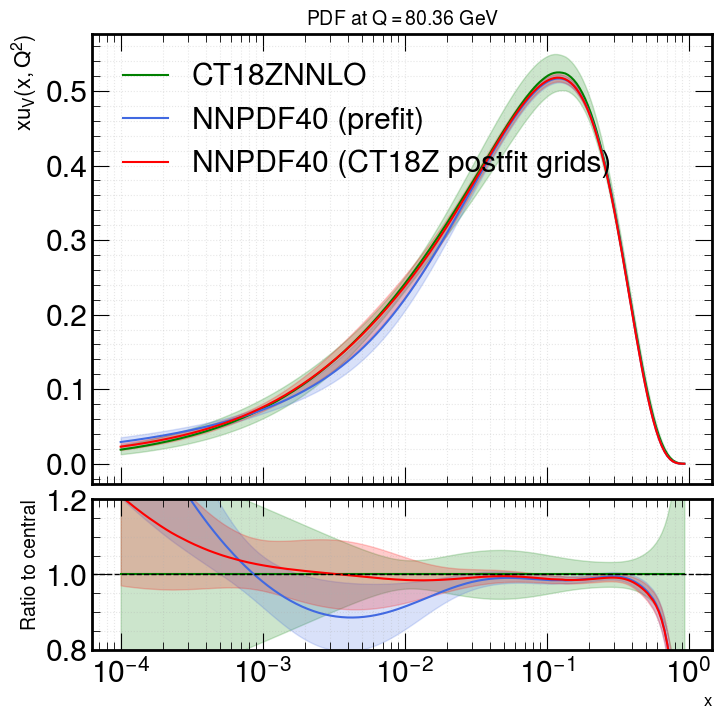

In [89]:
make_pdf_plot(vals2, errors2, x_range, ["CT18ZNNLO", "NNPDF40 (prefit)", "NNPDF40 (CT18Z postfit grids)"], colors)

In [95]:
vals_post, errors_post = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled"])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/GenFits/ZGen_ptVgen_absYVgen_nnpdf40_pdCT18Z/NNPDF40_uv_postfit.hdf5", ["postfit"])
vals_post.extend(vals_temp)
errors_post.extend(errs_temp)

NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled
LHAPDF 6.5.5 loading all 51 PDFs in set NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled
NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled, version 1; 51 PDF members


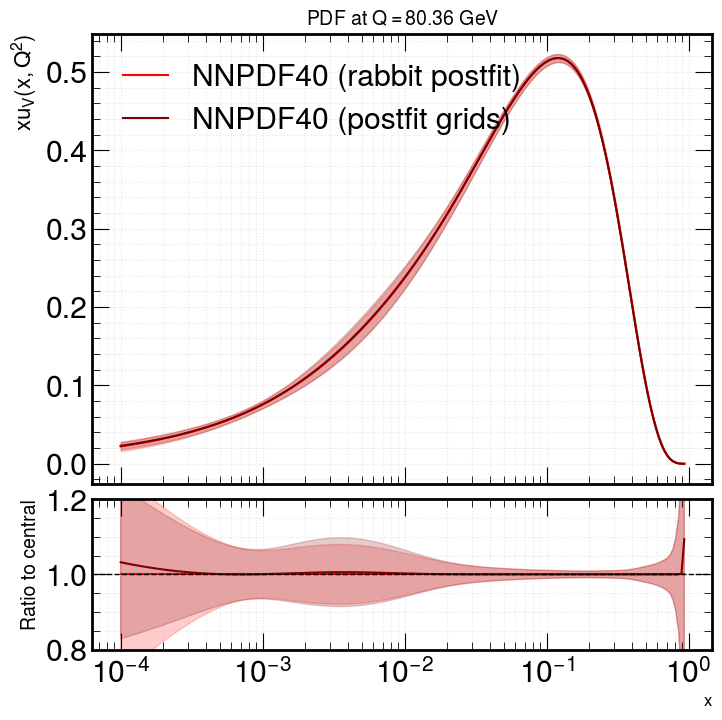

In [96]:
make_pdf_plot(vals_post, errors_post, x_range, ["NNPDF40 (rabbit postfit)", "NNPDF40 (postfit grids)"], ["red", "maroon"])

In [100]:
vals_pre, errors_pre = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["NNPDF40_nnlo_hessian_pdfas"])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/GenFits/ZGen_ptVgen_absYVgen_nnpdf40_pdCT18Z/NNPDF40_uv_postfit.hdf5", ["prefit"])
vals_pre.extend(vals_temp)
errors_pre.extend(errs_temp)

NNPDF40_nnlo_hessian_pdfas
LHAPDF 6.5.5 loading all 53 PDFs in set NNPDF40_nnlo_hessian_pdfas
NNPDF40_nnlo_hessian_pdfas, version 1; 53 PDF members


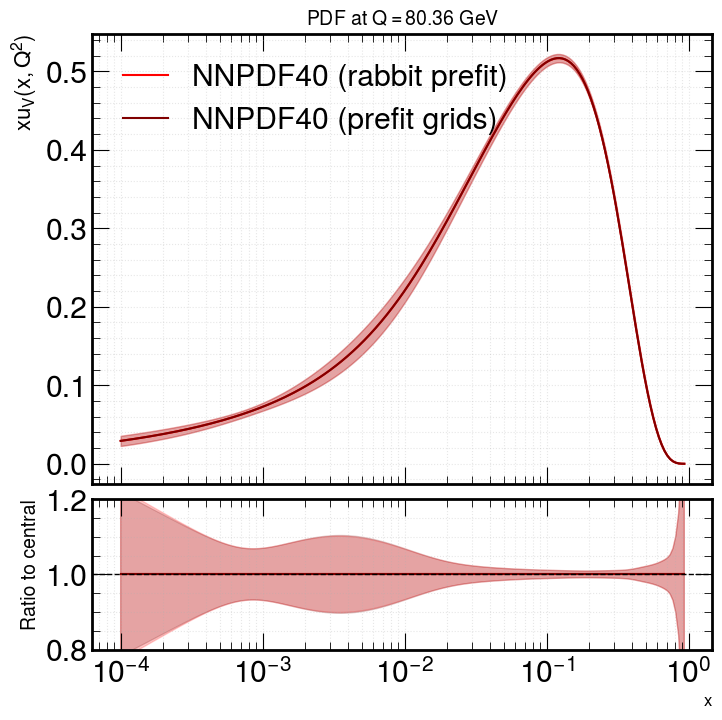

In [101]:
make_pdf_plot(vals_pre, errors_pre, x_range, ["NNPDF40 (rabbit prefit)", "NNPDF40 (prefit grids)"], ["red", "maroon"])

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


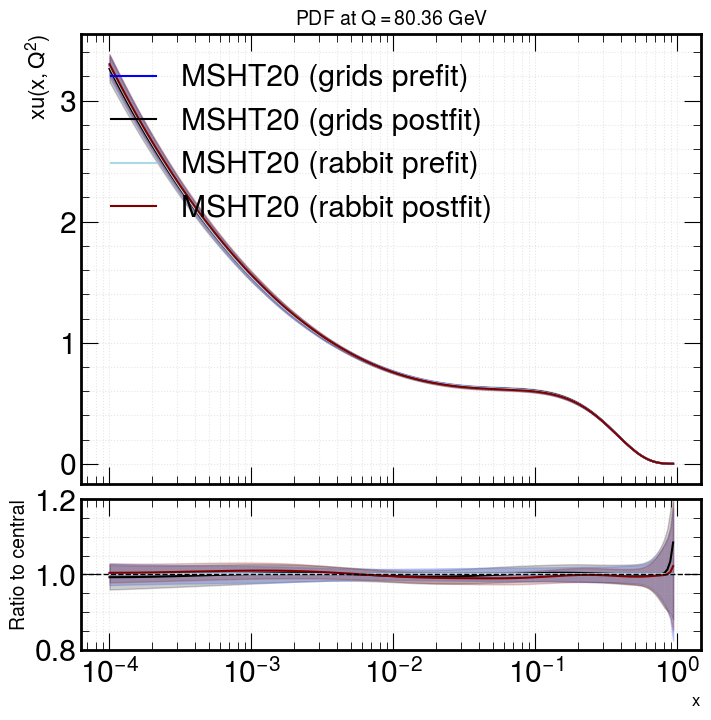

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


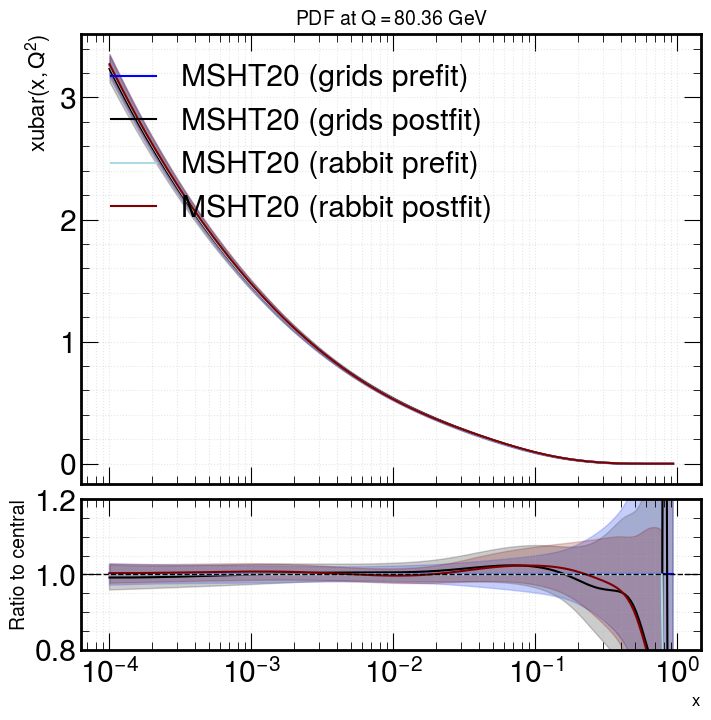

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


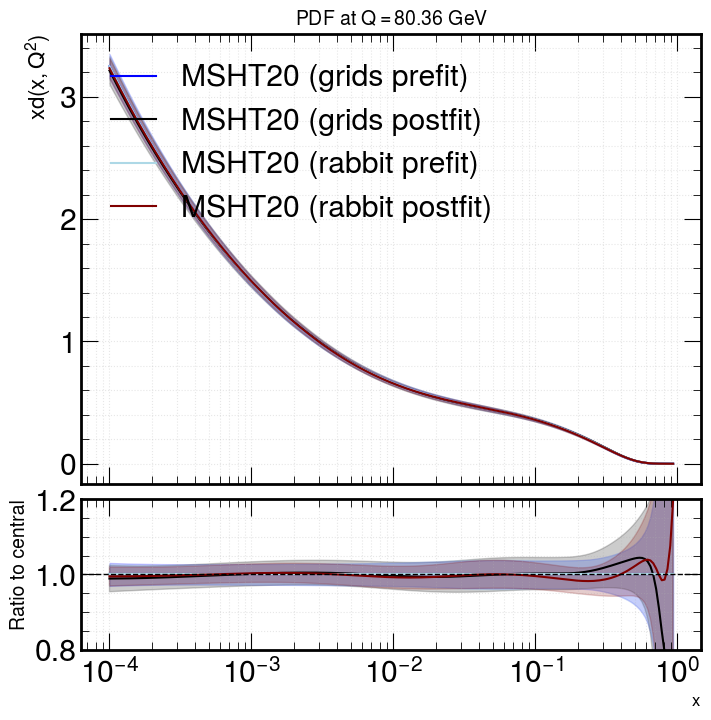

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


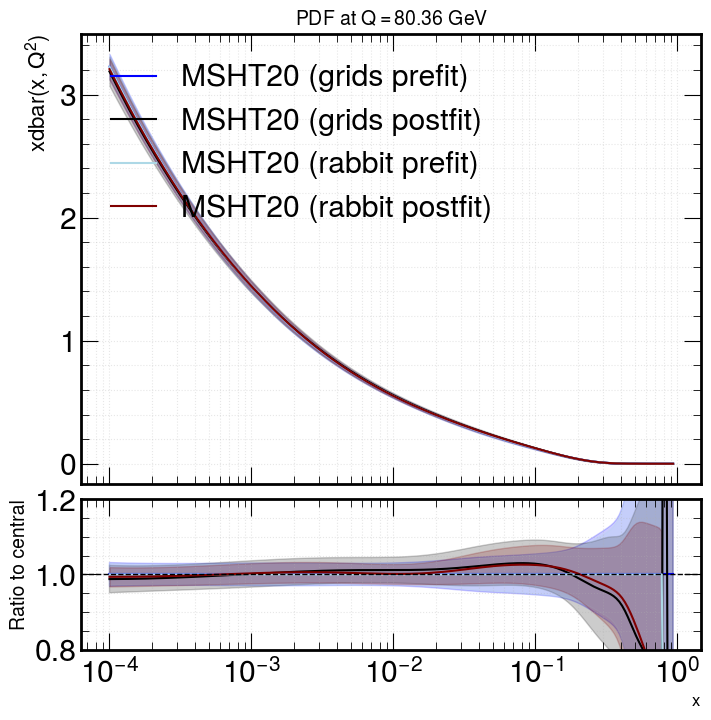

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


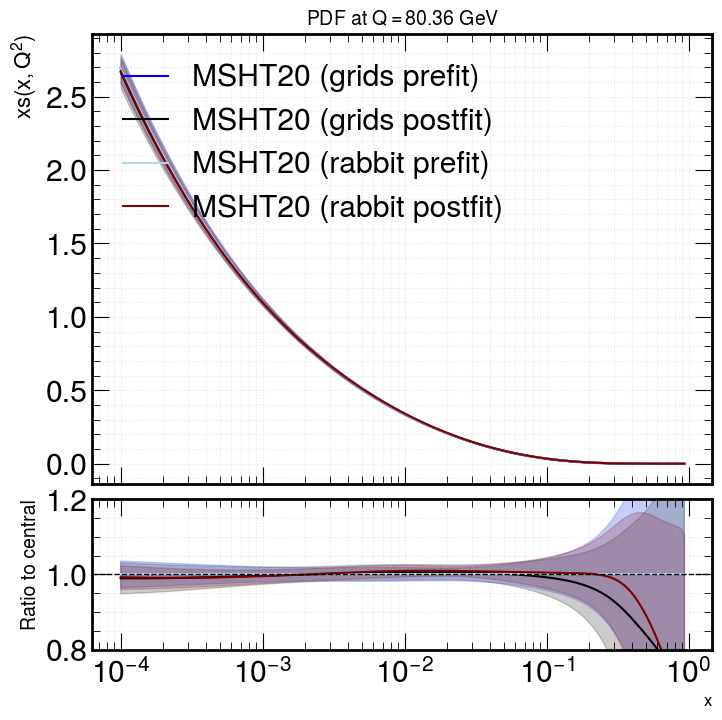

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


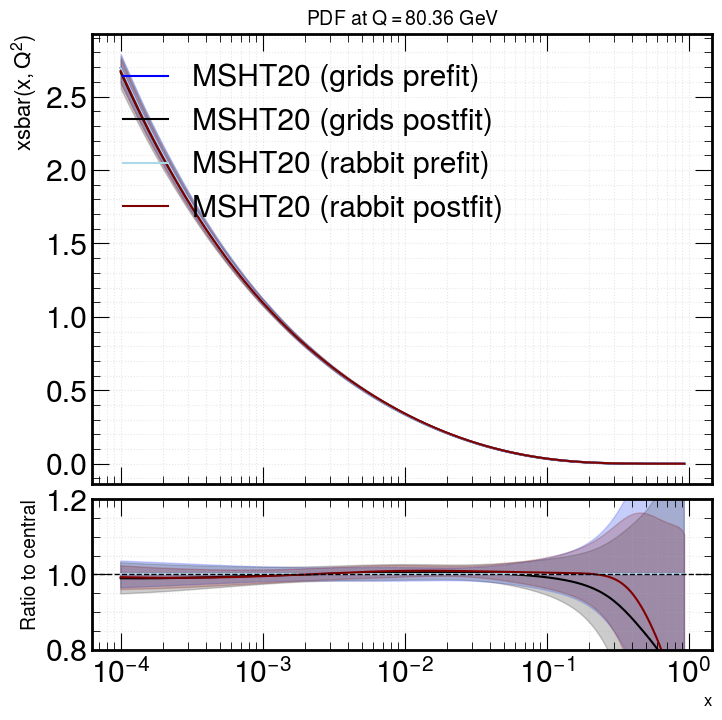

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


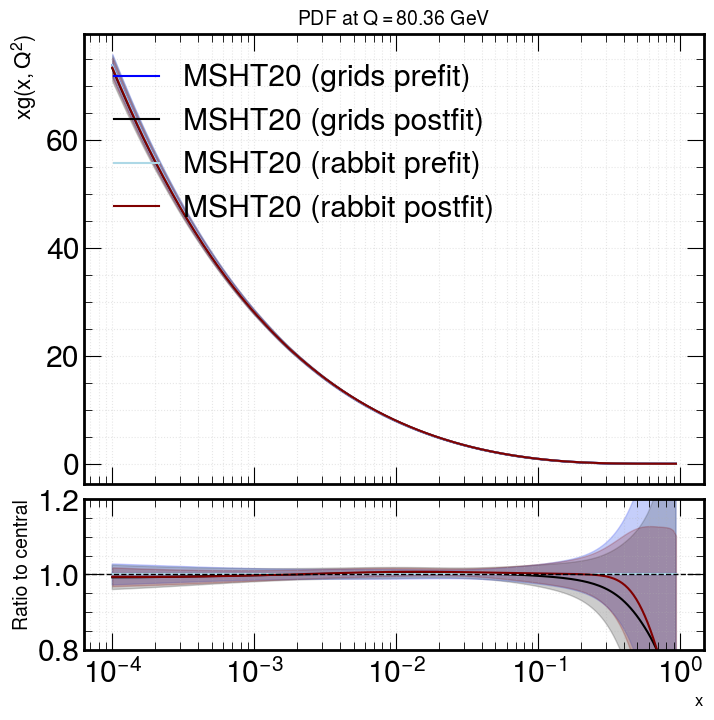

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


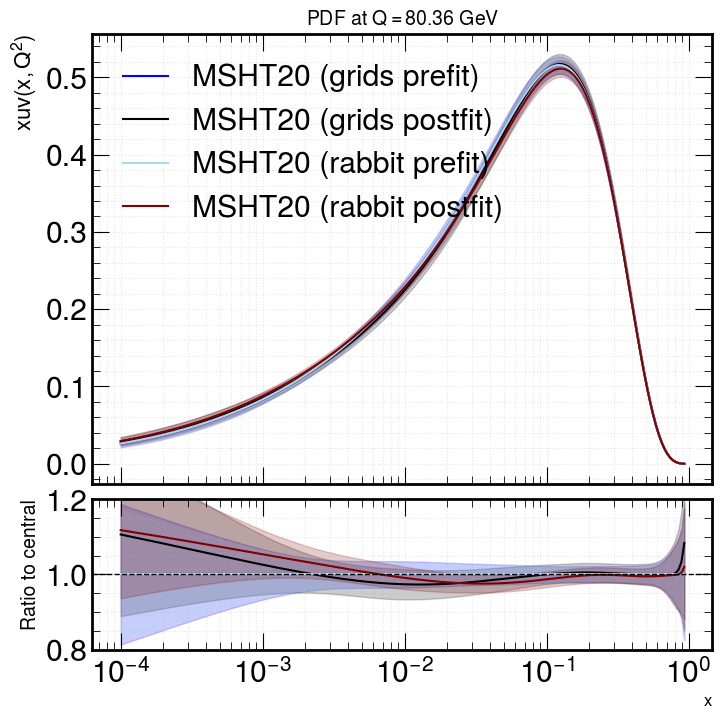

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_unscaled


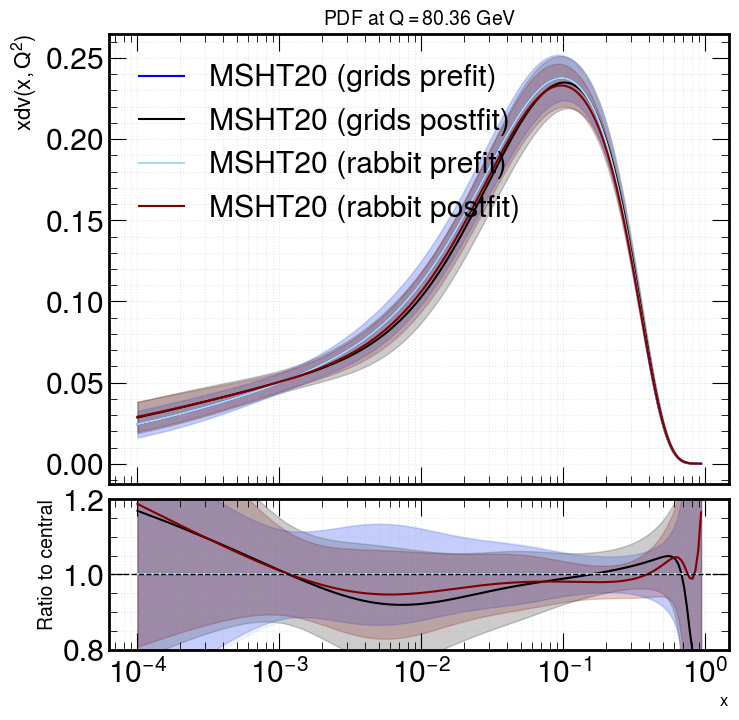

LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as11

In [164]:
for flavor in ["u", "ubar", "d", "dbar", "s", "sbar", "g", "uv", "dv"]:
    vals, errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["MSHT20nnlo_as118", "MSHT20nnlo_as118_cmsmw_unscaled", ])
    vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled/MSHT20_postfit.hdf5", ["prefit", "postfit"], flavor)
    vals.extend(vals_temp)
    errors.extend(errs_temp)
    make_pdf_plot(vals, errors, x_range, ["MSHT20 (grids prefit)", "MSHT20 (grids postfit)", "MSHT20 (rabbit prefit)", "MSHT20 (rabbit postfit)"], ["blue", "black", "lightblue", "maroon"])


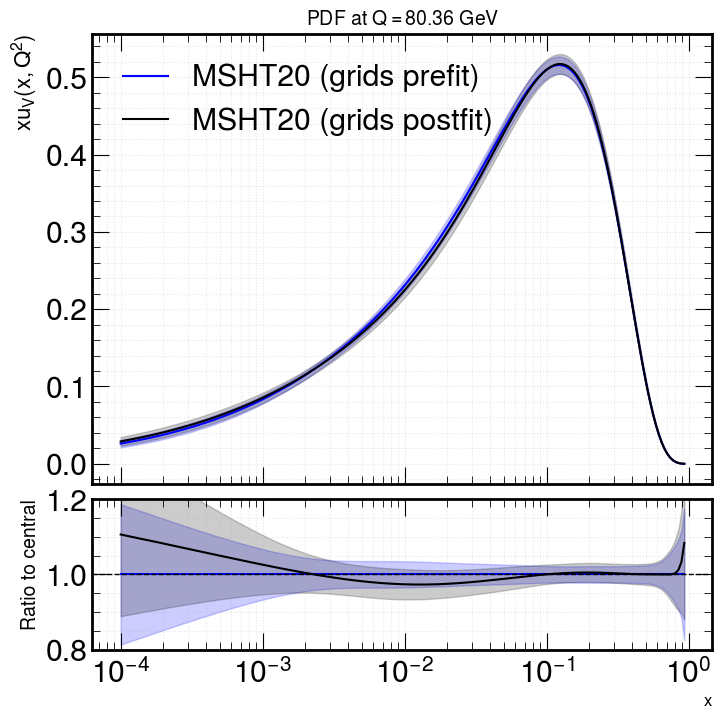

In [147]:
make_pdf_plot(vals[:2], errors[:2], x_range, ["MSHT20 (grids prefit)", "MSHT20 (grids postfit)",], ["blue", "black",])

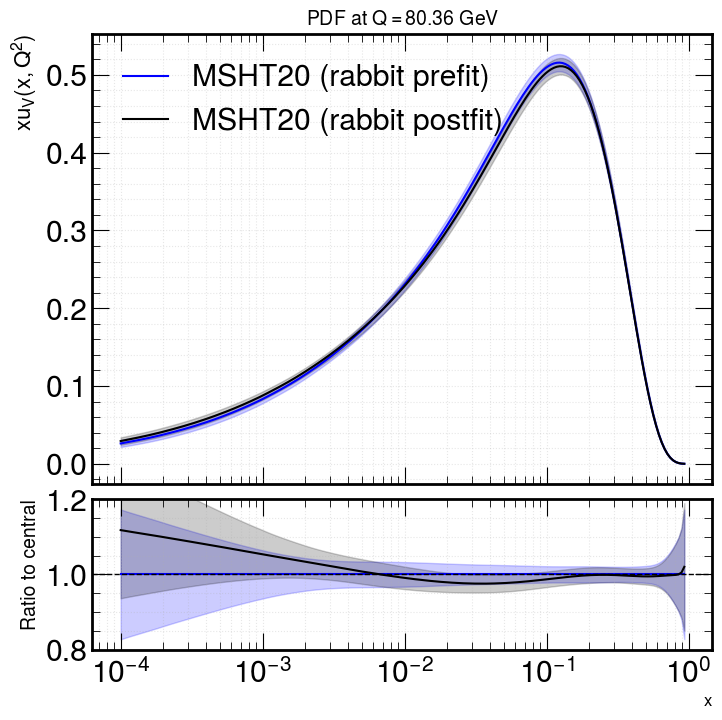

In [148]:
make_pdf_plot(vals[2:], errors[2:], x_range, ["MSHT20 (rabbit prefit)", "MSHT20 (rabbit postfit)",], ["blue", "black",])

CT18ZNNLO
CT18ZNNLO_cmsmw_unscaled


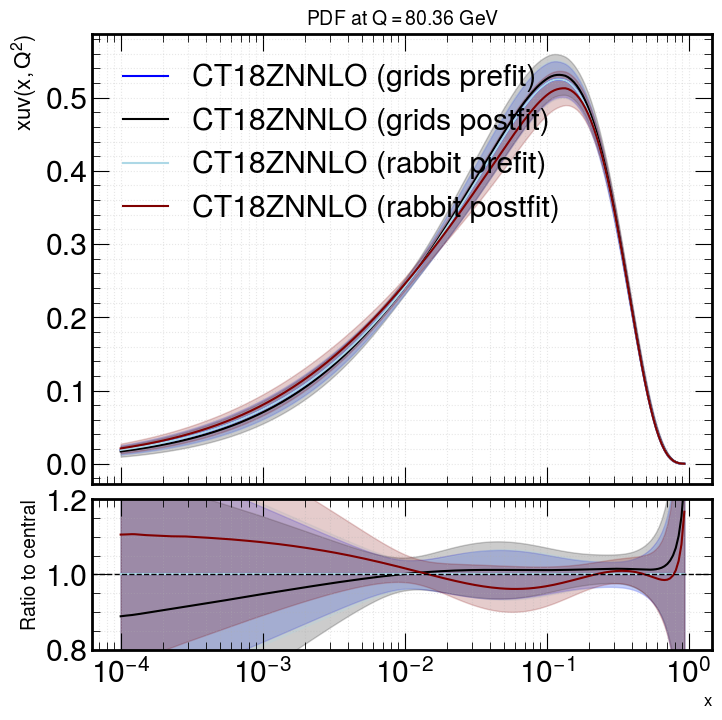

LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO
CT18ZNNLO, version 1; 59 PDF members
LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO_cmsmw_unscaled
CT18ZNNLO_cmsmw_unscaled, version 1; 59 PDF members


In [187]:
flavor = "uv"
vals, errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["CT18ZNNLO", "CT18ZNNLO_cmsmw_unscaled",])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_nominal/CT18Z_postfit.hdf5", ["prefit", "postfit"], flavor)
vals.extend(vals_temp)
errors.extend(errs_temp)
make_pdf_plot(vals, errors, x_range, ["CT18ZNNLO (grids prefit)", "CT18ZNNLO (grids postfit)", "CT18ZNNLO (rabbit prefit)", "CT18ZNNLO (rabbit postfit)"], ["blue", "black", "lightblue", "maroon"])

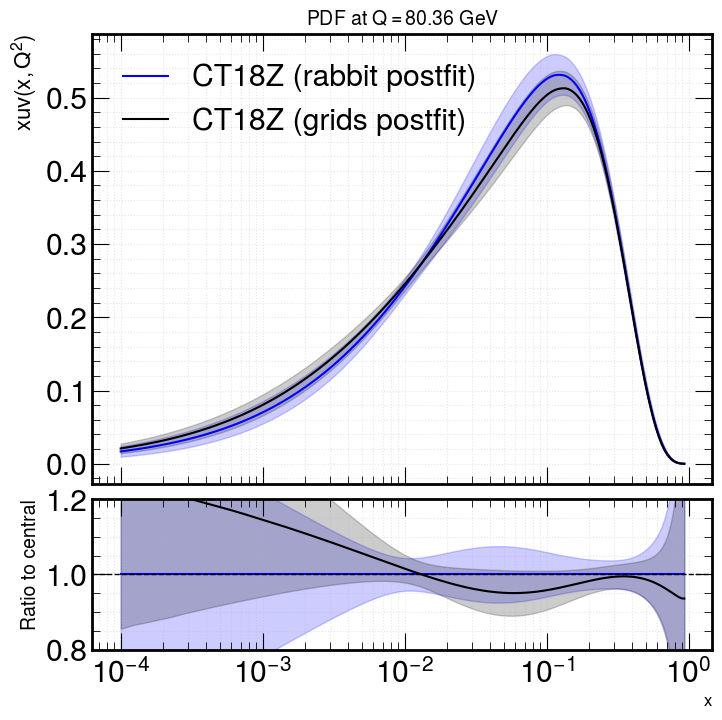

In [188]:
make_pdf_plot([vals[1], vals[3]], [errors[1], errors[3]], x_range, ["CT18Z (rabbit postfit)", "CT18Z (grids postfit)",], ["blue", "black",])

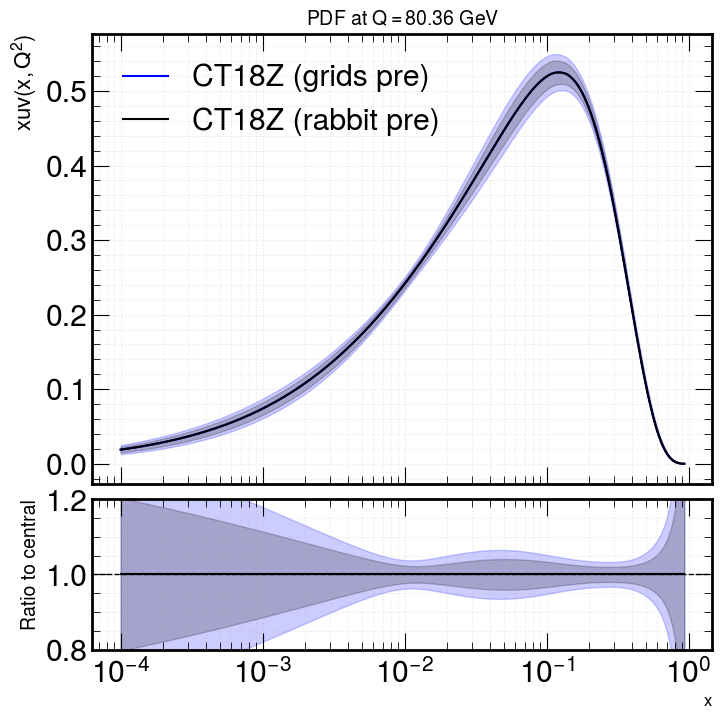

In [179]:
make_pdf_plot([vals[0], vals[2]], [errors[0], errors[2]], x_range, ["CT18Z (grids pre)", "CT18Z (rabbit pre)",], ["blue", "black",])

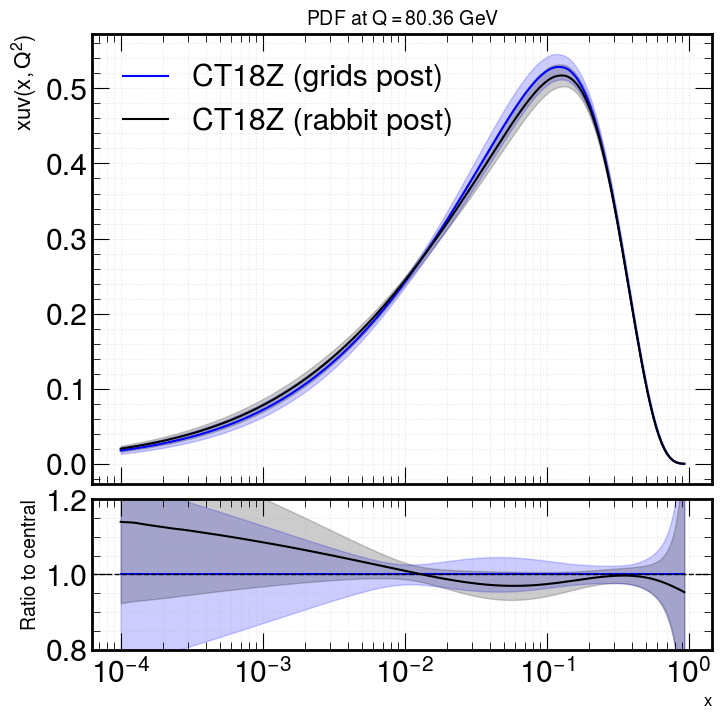

In [180]:
make_pdf_plot([vals[1], vals[3]], [errors[1], errors[3]], x_range, ["CT18Z (grids post)", "CT18Z (rabbit post)",], ["blue", "black",])

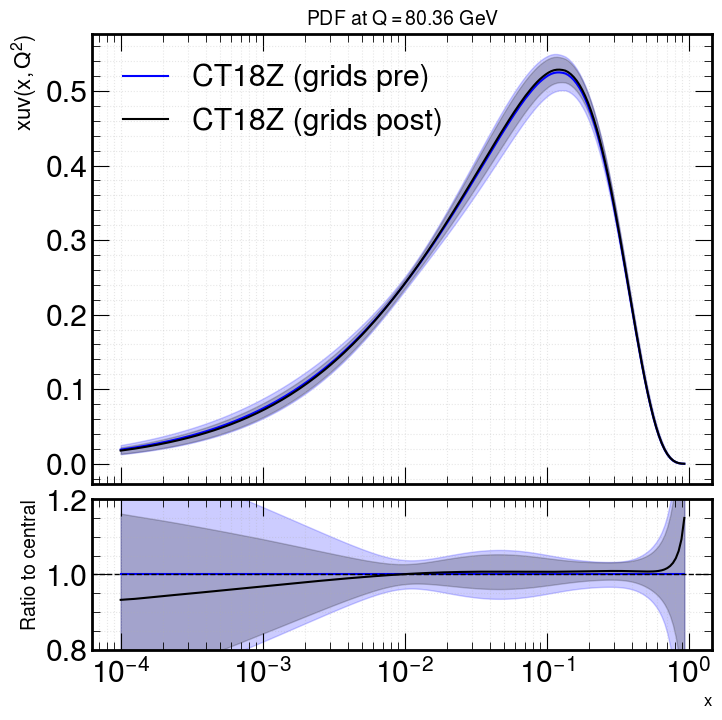

In [182]:
make_pdf_plot([vals[0], vals[1]], [errors[0], errors[1]], x_range, ["CT18Z (grids pre)", "CT18Z (grids post)",], ["blue", "black",])

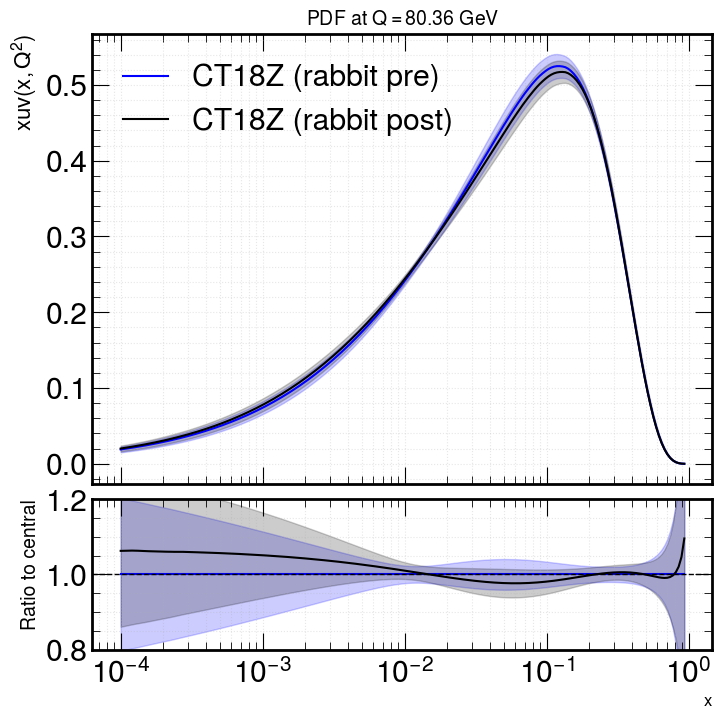

In [183]:
make_pdf_plot([vals[2], vals[3]], [errors[2], errors[3]], x_range, ["CT18Z (rabbit pre)", "CT18Z (rabbit post)",], ["blue", "black",])

CT18ZNNLO
CT18ZNNLO_cmsmw_unscaled


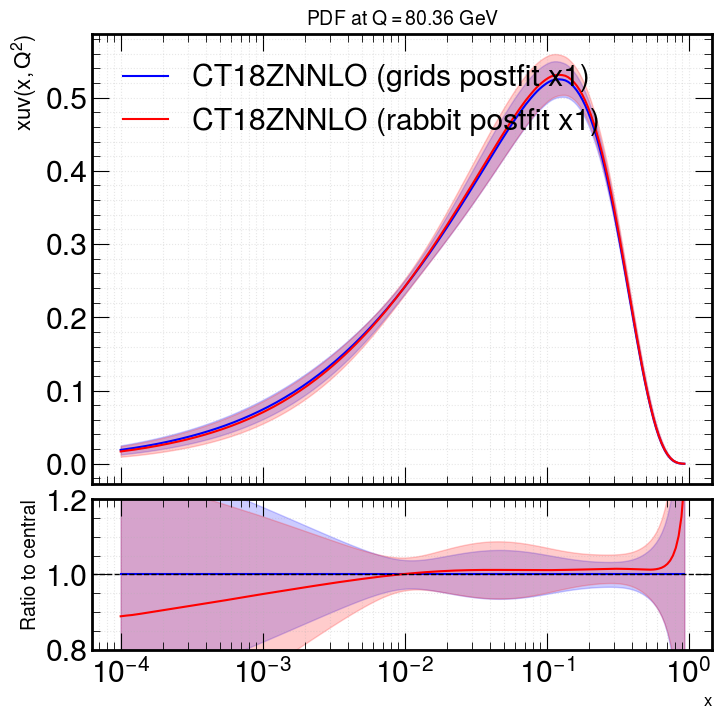

LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO
CT18ZNNLO, version 1; 59 PDF members
LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO_cmsmw_unscaled
CT18ZNNLO_cmsmw_unscaled, version 1; 59 PDF members


In [189]:
flavor = "uv"
vals, errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["CT18ZNNLO", "CT18ZNNLO_cmsmw_unscaled",])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_nominal/CT18Z_postfit.hdf5", ["prefit", "postfit"], flavor)
vals.extend(vals_temp)
errors.extend(errs_temp)
make_pdf_plot(vals, errors, x_range, ["CT18ZNNLO (grids postfit x1)", "CT18ZNNLO (rabbit postfit x1)"], ["blue", "red",])

CT18ZNNLO
CT18ZNNLO_cmsmw_uncx0p6


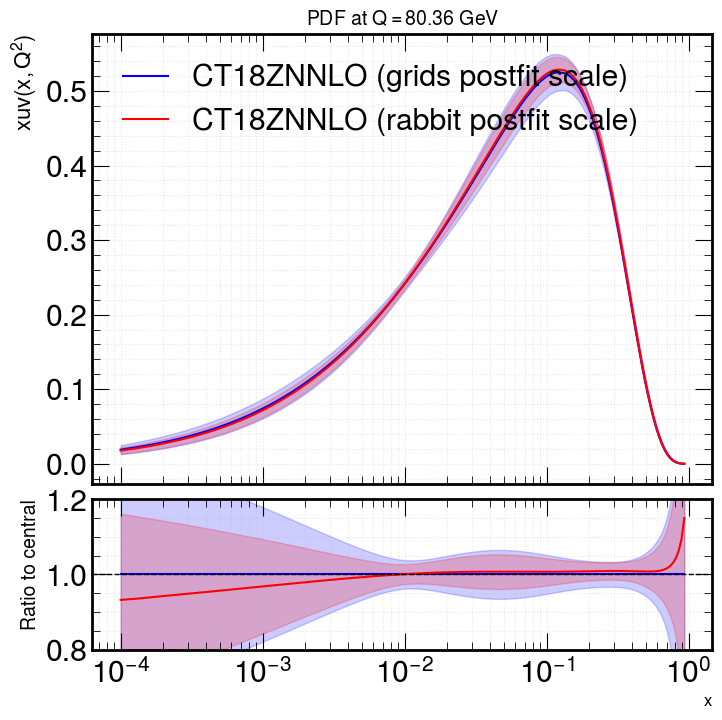

LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO
CT18ZNNLO, version 1; 59 PDF members
LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO_cmsmw_uncx0p6
CT18ZNNLO_cmsmw_uncx0p6, version 1; 59 PDF members


In [190]:
flavor = "uv"
vals, errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["CT18ZNNLO", "CT18ZNNLO_cmsmw_uncx0p6",])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_nominal/CT18Z_postfit_scaled.hdf5", ["prefit", "postfit"], flavor)
vals.extend(vals_temp)
errors.extend(errs_temp)
make_pdf_plot(vals, errors, x_range, ["CT18ZNNLO (grids postfit scale)", "CT18ZNNLO (rabbit postfit scale)"], ["blue", "red",])

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


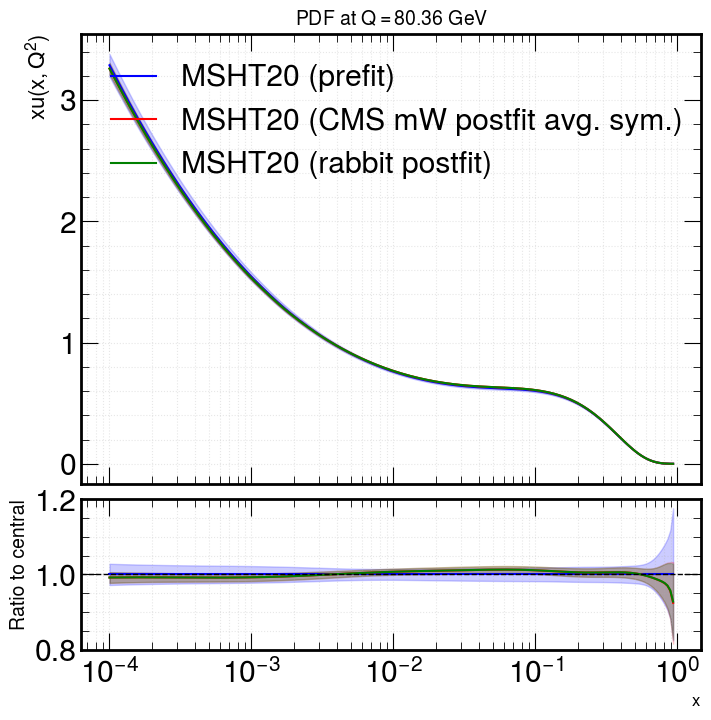

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


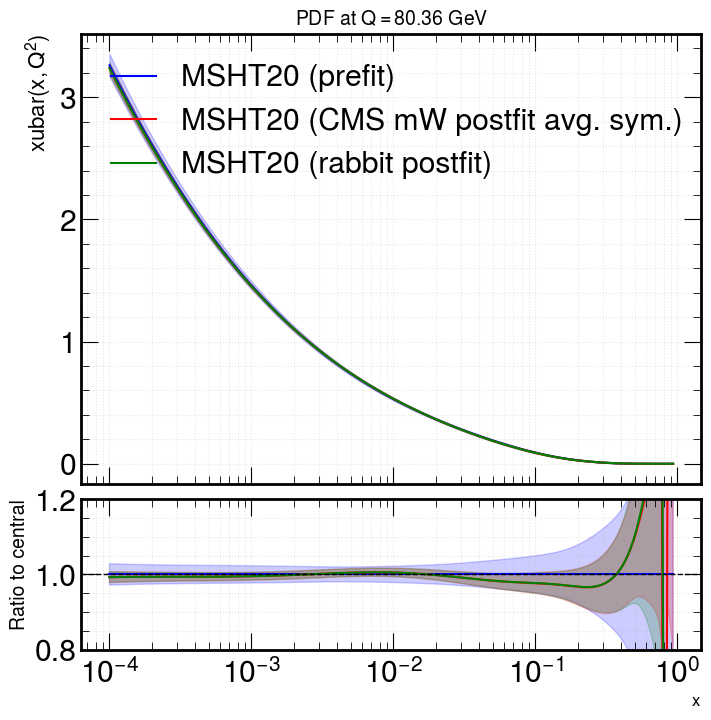

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


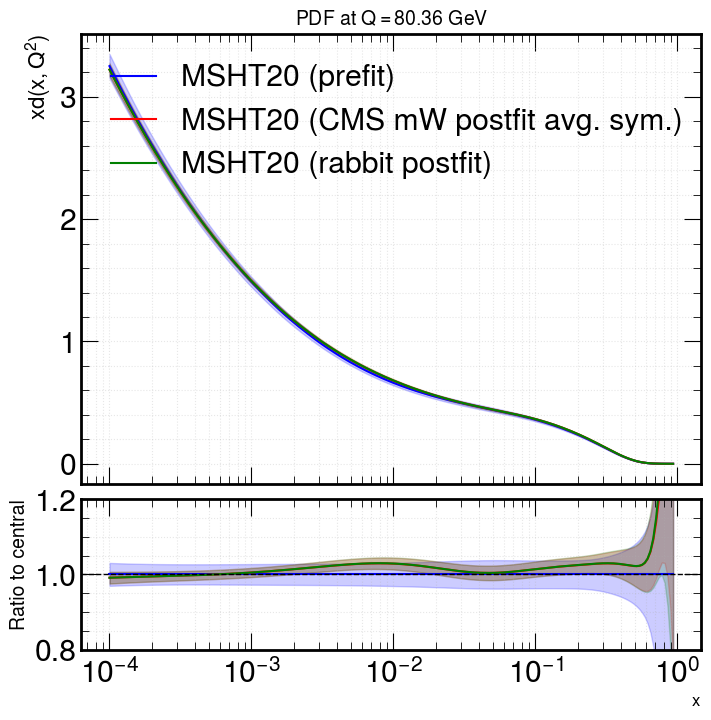

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


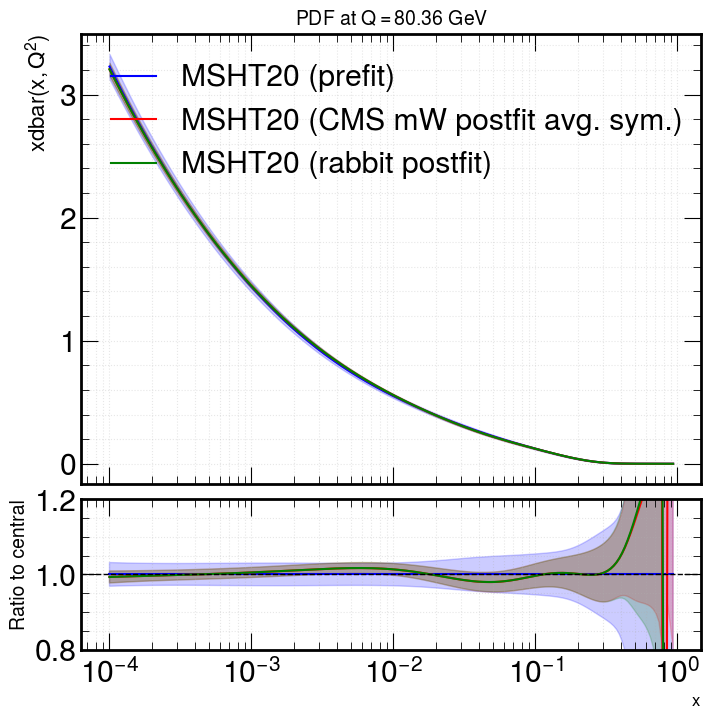

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


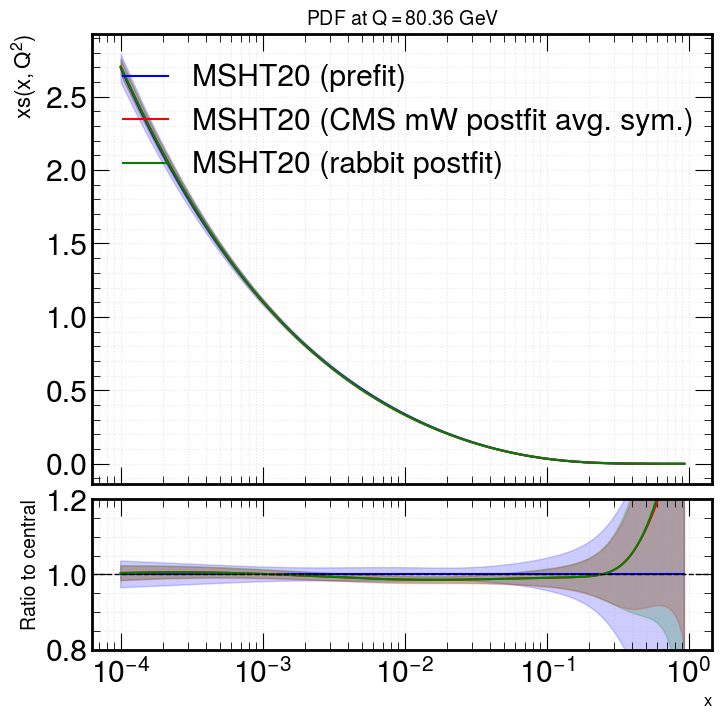

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


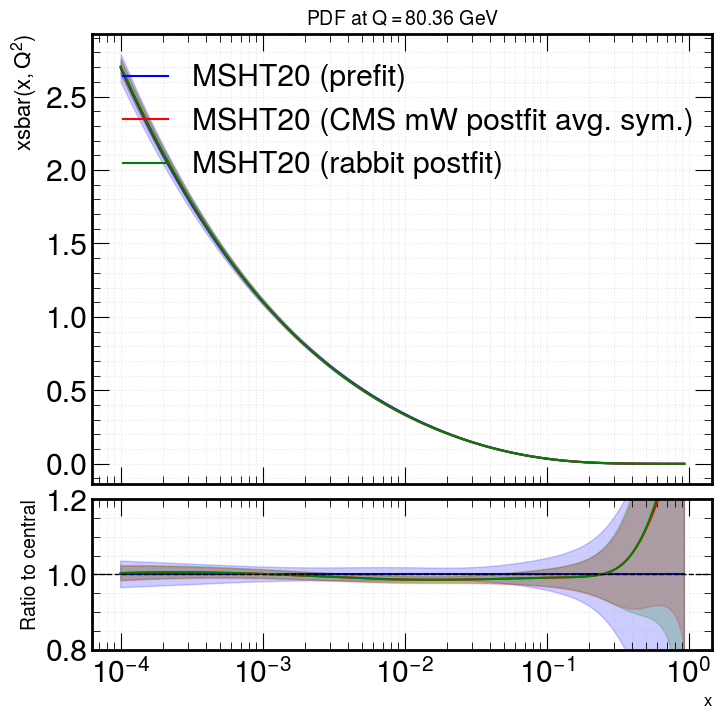

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


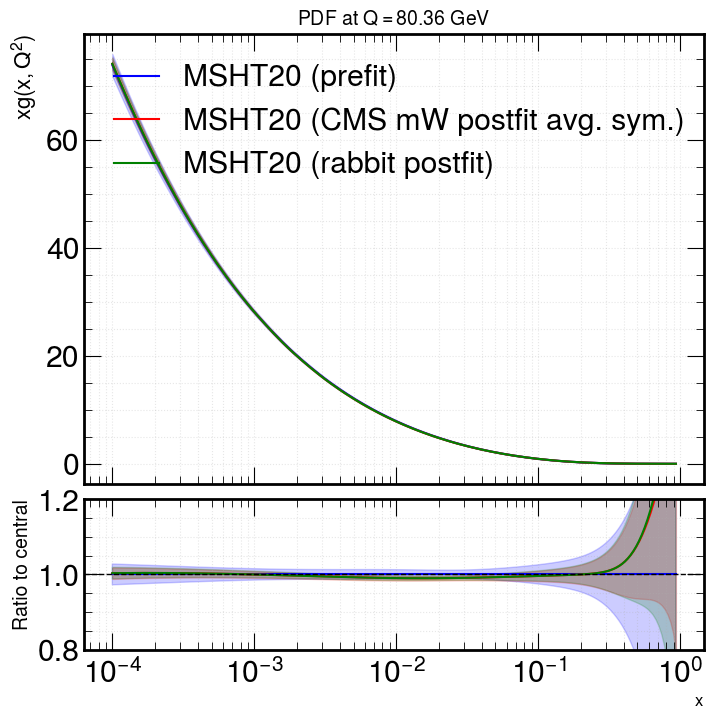

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


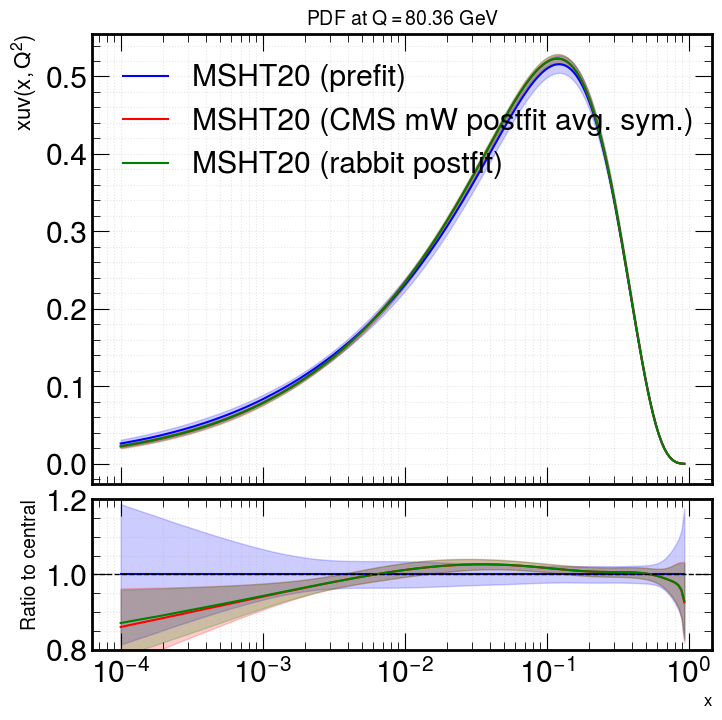

MSHT20nnlo_as118
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled


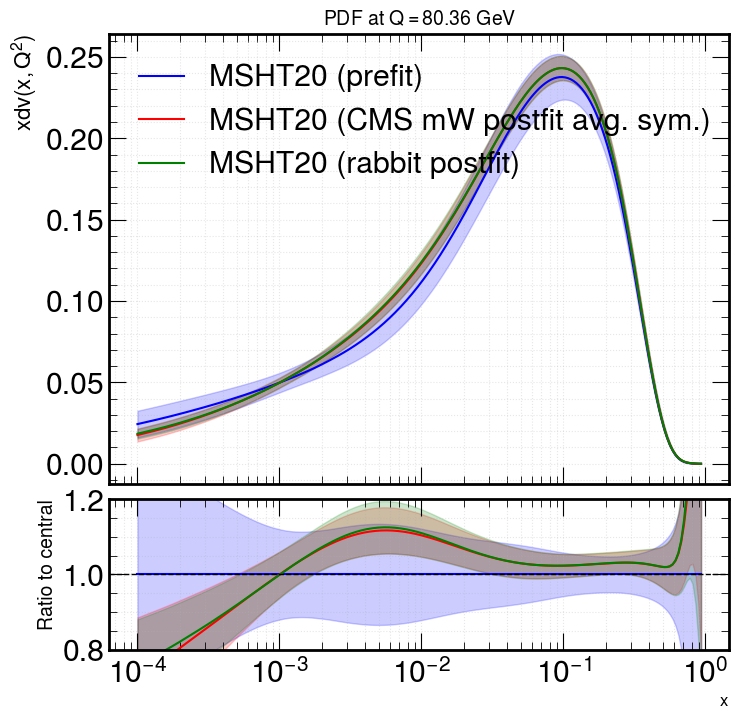

LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 33 PDFs in set MSHT20nnlo_as118_cmsmw_avgsymm_unscaled
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled, version 4; 33 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 33 PDFs in set MSHT20nnlo_as118_cmsmw_avgsymm_unscaled
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled, version 4; 33 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 33 PDFs in set MSHT20nnlo_as118_cmsmw_avgsymm_unscaled
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled, version 4; 33 PDF members
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
LHAPDF 6.5.5 loading all 33 PDFs in set MSHT20nnlo_as118_cmsmw_avgsymm_unscaled
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled, version 4; 33 PDF members
LHAPDF 6

In [266]:
for flavor in ["u", "ubar", "d", "dbar", "s", "sbar", "g", "uv", "dv"]:
    vals, errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["MSHT20nnlo_as118", "MSHT20nnlo_as118_cmsmw_avgsymm_unscaled"])
    vals_tmp,errors_tmp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled_symavg/MSHT20_symavg_postfit.hdf5", ["postfit"], flavor)
    vals.extend(vals_tmp)
    errors.extend(errors_tmp)
    make_pdf_plot(vals, errors, x_range, ["MSHT20 (prefit)", "MSHT20 (CMS mW postfit avg. sym.)", "MSHT20 (rabbit postfit)"], ["blue", "red", "green", ])


MSHT20nnlo_as118
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
64 65
MSHT20nnlo_as118_cmsmw_unscaled
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
64 65
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled
LHAPDF 6.5.5 loading all 33 PDFs in set MSHT20nnlo_as118_cmsmw_avgsymm_unscaled
MSHT20nnlo_as118_cmsmw_avgsymm_unscaled, version 4; 33 PDF members
32 33


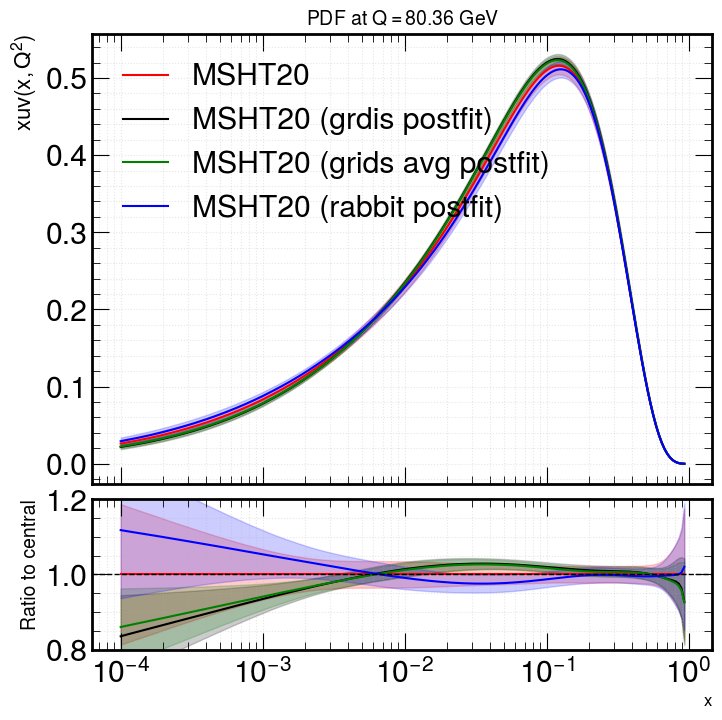

In [23]:
#for flavor in ["u", "ubar", "d", "dbar", "s", "sbar", "g", "uv", "dv"]:
x_range = np.logspace(-4, -0.01, 201)[:-1]

for flavor in ["uv",]:
    vals,errors = read_pdf_vals_and_errors(flavor, mw, x_range, ["MSHT20nnlo_as118", "MSHT20nnlo_as118_cmsmw_unscaled", "MSHT20nnlo_as118_cmsmw_avgsymm_unscaled"])
    vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled/MSHT20_postfit.hdf5", ["postfit"], flavor)
    vals.extend(vals_temp)
    errors.extend(errs_temp)
    make_pdf_plot(vals, errors, x_range, ["MSHT20", "MSHT20 (grdis postfit)", "MSHT20 (grids avg postfit)", "MSHT20 (rabbit postfit)", ], ["red", "black", "green", "blue"])
    #make_pdf_plot(vals, errors, x_range, ["MSHT20 (avg rabbit prefit)", "MSHT20 (avg rabbit postfit)", "MSHT20 (grids postfit avg symm)"], ["red", "black", "green",]) 

NNPDF40_nnlo_hessian_pdfas
LHAPDF 6.5.5 loading all 53 PDFs in set NNPDF40_nnlo_hessian_pdfas
NNPDF40_nnlo_hessian_pdfas, version 1; 53 PDF members
50 51
NNPDF40_nnlo_hessian_pdfas_cmsmw_unscaled
LHAPDF 6.5.5 loading all 51 PDFs in set NNPDF40_nnlo_hessian_pdfas_cmsmw_unscaled
NNPDF40_nnlo_hessian_pdfas_cmsmw_unscaled, version 1; 51 PDF members
50 51


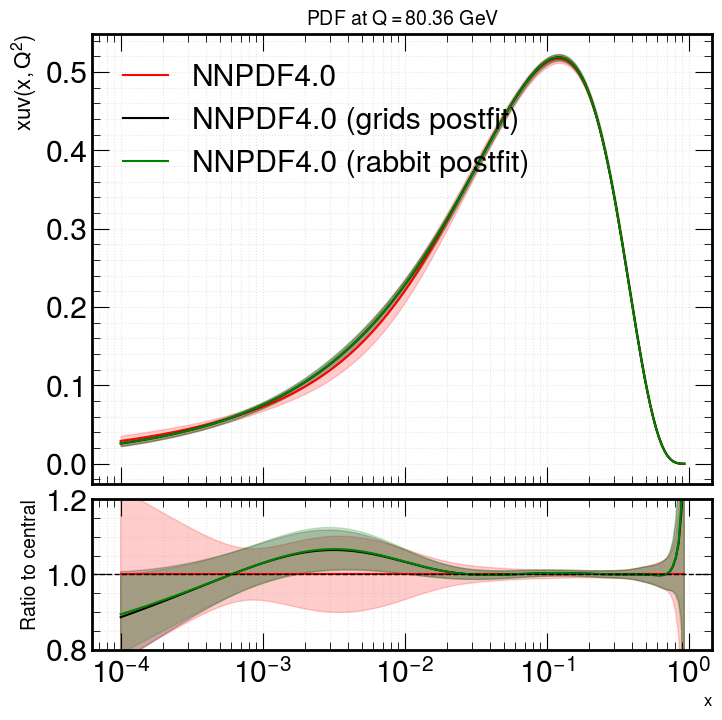

In [25]:
#for flavor in ["u", "ubar", "d", "dbar", "s", "sbar", "g", "uv", "dv"]:
x_range = np.logspace(-4, -0.01, 201)[:-1]

for flavor in ["uv",]:
    vals,errors = read_pdf_vals_and_errors(flavor, mw, x_range, ["NNPDF40_nnlo_hessian_pdfas", "NNPDF40_nnlo_hessian_pdfas_cmsmw_unscaled",])
    vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_nnpdf40/NNPDF40_postfit.hdf5", ["postfit"], flavor)
    vals.extend(vals_temp)
    errors.extend(errs_temp)
    make_pdf_plot(vals, errors, x_range, ["NNPDF4.0", "NNPDF4.0 (grids postfit)", "NNPDF4.0 (rabbit postfit)", ], ["red", "black", "green",])
    #make_pdf_plot(vals, errors, x_range, ["MSHT20 (avg rabbit prefit)", "MSHT20 (avg rabbit postfit)", "MSHT20 (grids postfit avg symm)"], ["red", "black", "green",]) 

NNPDF40_nnlo_hessian_pdfas
LHAPDF 6.5.5 loading all 53 PDFs in set NNPDF40_nnlo_hessian_pdfas
NNPDF40_nnlo_hessian_pdfas, version 1; 53 PDF members
50 51
MSHT20nnlo_as118
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
64 65
MSHT20nnlo_as118_cmsmw_unscaled
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
64 65


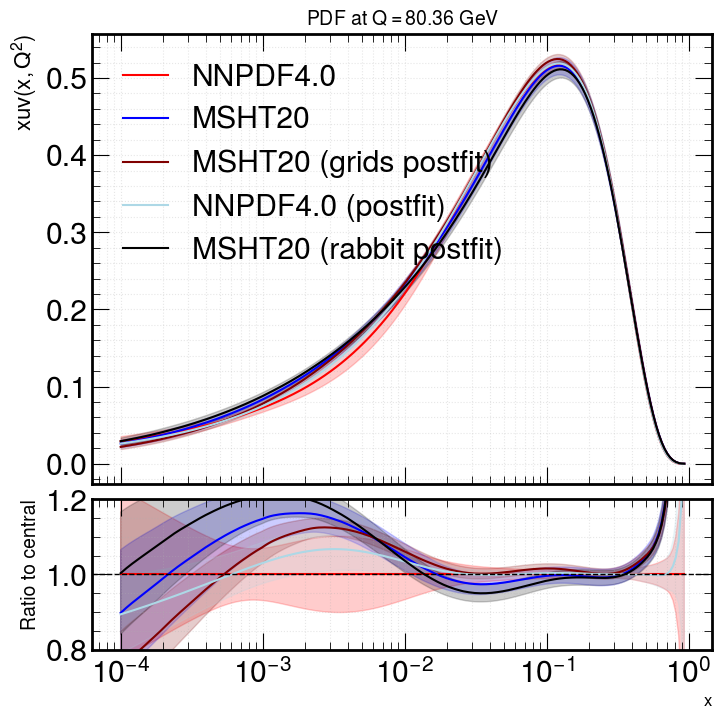

In [31]:
for flavor in ["uv",]:
    vals,errors = read_pdf_vals_and_errors(flavor, mw, x_range, ["NNPDF40_nnlo_hessian_pdfas", "MSHT20nnlo_as118", "MSHT20nnlo_as118_cmsmw_unscaled"])
    vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_nnpdf40/NNPDF40_postfit.hdf5", ["postfit"], flavor)
    vals.extend(vals_temp)
    errors.extend(errs_temp)
    vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled/MSHT20_postfit.hdf5", ["postfit"], flavor)
    vals.extend(vals_temp)
    errors.extend(errs_temp)
    make_pdf_plot(vals, errors, x_range, ["NNPDF4.0", "MSHT20", "MSHT20 (grids postfit)", "NNPDF4.0 (postfit)", "MSHT20 (rabbit postfit)", ], ["red", "blue", "maroon", "lightblue", "black"])
    #make_pdf_plot(vals, errors, x_range, ["MSHT20 (avg rabbit prefit)", "MSHT20 (avg rabbit postfit)", "MSHT20 (grids postfit avg symm)"], ["red", "black", "green",]) 

LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
64 65
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
64 65
SYMMETRIC HESSIAN: Using same error for up and down


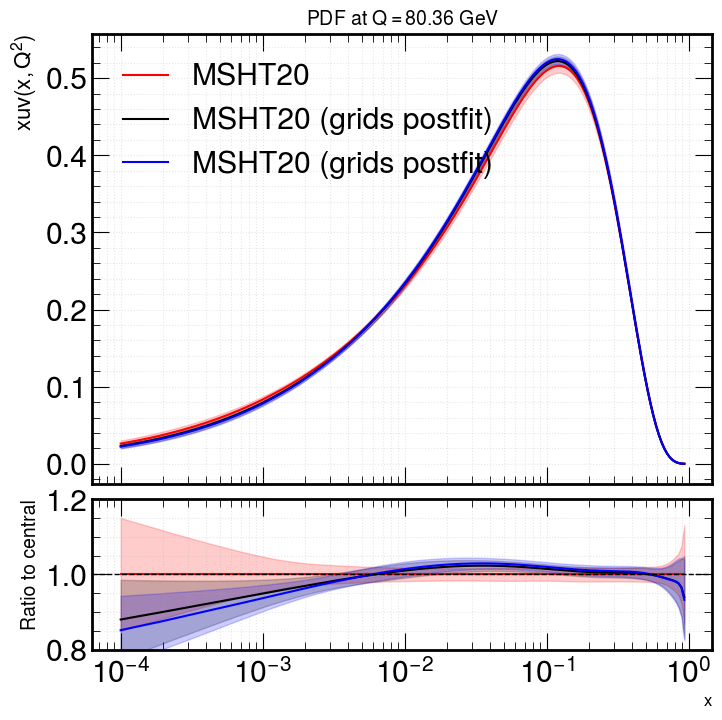

In [33]:
Q_scale = mw
x_range = np.logspace(-4, -0.01, 201)[:-1]
for flavor in ["uv",]:
    vals,errors = theory_utils.read_pdf_vals_and_errors(flavor, mw, x_range, ["MSHT20nnlo_as118", "MSHT20nnlo_as118_cmsmw_unscaled",])
    #vals_temp,errs_temp = theory_utils.read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled_symavg/MSHT20_symavg_new_postfit.hdf5", ["postfit"], flavor)
    #vals.extend(vals_temp)
    errors.extend(errs_temp)
    vals_temp,errs_temp = theory_utils.read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled/MSHT20_postfit.hdf5", ["postfit"], flavor)
    vals.extend(vals_temp)
    errors.extend(errs_temp)
    errors = [e[0] for e in errors]
    make_pdf_plot_old(vals, errors, x_range, ["MSHT20", "MSHT20 (grids postfit)", "MSHT20 (grids postfit)"], ["red", "black", "blue",])

LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118
MSHT20nnlo_as118, version 4; 65 PDF members
64 65
LHAPDF 6.5.5 loading all 65 PDFs in set MSHT20nnlo_as118_cmsmw_unscaled
MSHT20nnlo_as118_cmsmw_unscaled, version 4; 65 PDF members
64 65
SYMMETRIC HESSIAN: Using same error for up and down


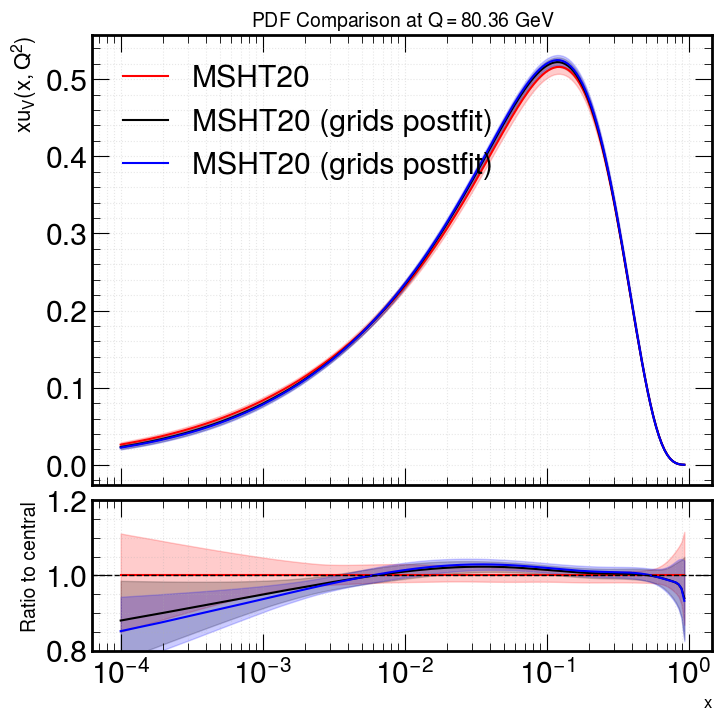

In [55]:
from scripts.plotting.plot_pdfs_imp import make_pdf_plot
vals,errors = theory_utils.read_pdf_vals_and_errors(flavor, mw, x_range, ["MSHT20nnlo_as118", "MSHT20nnlo_as118_cmsmw_unscaled",])
errors.extend(errs_temp)
vals_temp,errs_temp = theory_utils.read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/Unblinded/WMass_eta_pt_charge_msht20_unscaled/MSHT20_postfit.hdf5", ["postfit"], flavor)
vals.extend(vals_temp)
errors.extend(errs_temp)
make_pdf_plot("uv", Q_scale, x_range, vals, errors, ["MSHT20", "MSHT20 (grids postfit)", "MSHT20 (grids postfit)"], ["red", "black", "blue", ], "temp", None)


LHAPDF 6.5.5 loading all 43 PDFs in set PDF4LHC21_40_pdfas
PDF4LHC21_40_pdfas, version 1; 43 PDF members
40 41
SYMMETRIC HESSIAN: Using same error for up and down
LHAPDF 6.5.5 loading all 41 PDFs in set PDF4LHC21_40_pdfas_cmsmw_unscaled
PDF4LHC21_40_pdfas_cmsmw_unscaled, version 1; 41 PDF members
40 41
SYMMETRIC HESSIAN: Using same error for up and down


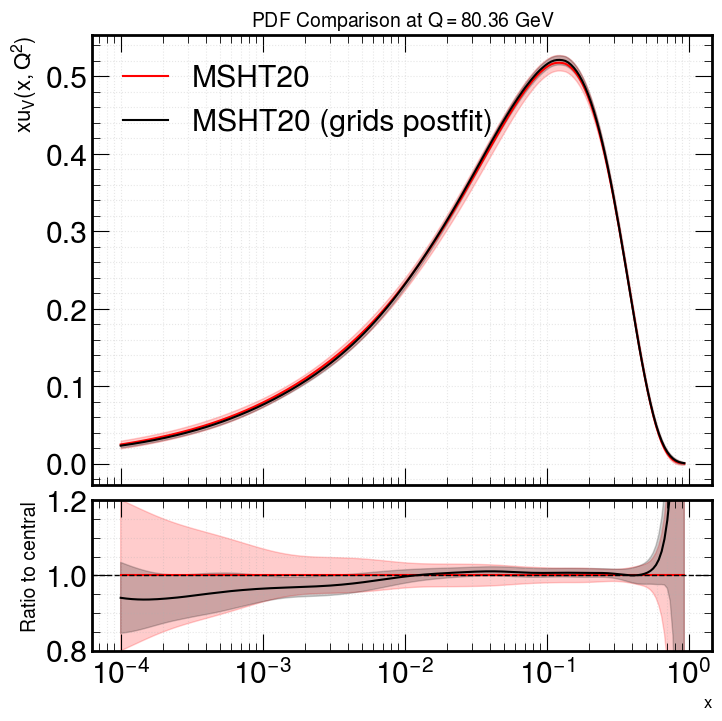

In [57]:
from scripts.plotting.plot_pdfs_imp import make_pdf_plot
vals,errors = theory_utils.read_pdf_vals_and_errors(flavor, mw, x_range, ["PDF4LHC21_40_pdfas", "PDF4LHC21_40_pdfas_cmsmw_unscaled",])
make_pdf_plot("uv", Q_scale, x_range, vals, errors, ["MSHT20", "MSHT20 (grids postfit)", ], ["red", "black", ], "temp", None)
